In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)####忽略警告

In [3]:
sp <- readRDS("./merge_red.RDS")

In [4]:
sp1 <- subset(sp,subset = celltype=="Microglia"&area%in%c("GCL","INL","ONL"))

In [5]:
library(msigdbr)

In [6]:
####gs
######GO KEGG
####let us find something
####GSVA genesets
genesets <- msigdbr(species = "Mus musculus", category = "C5")#msigdbr导入基因集
genesets <- subset(genesets, select = c("gs_name","gene_symbol")) %>% as.data.frame()#as data.frame
genesets$gs_name <- str_replace(genesets$gs_name,"GOBP_","")
head(genesets)
genesets$gs_name <- gsub("_", " ", genesets$gs_name)
genesets$gs_name <- tolower(substring(genesets$gs_name, 1))
# genesets <- split(genesets$gene_symbol, genesets$gs_name)#
head(genesets)

,gs_name,gene_symbol
,<chr>,<chr>
1,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aasdhppt
2,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aldh1l1
3,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aldh1l2
4,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd1
5,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd1l
6,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd2l


,gs_name,gene_symbol
,<chr>,<chr>
1,10 formyltetrahydrofolate metabolic process,Aasdhppt
2,10 formyltetrahydrofolate metabolic process,Aldh1l1
3,10 formyltetrahydrofolate metabolic process,Aldh1l2
4,10 formyltetrahydrofolate metabolic process,Mthfd1
5,10 formyltetrahydrofolate metabolic process,Mthfd1l
6,10 formyltetrahydrofolate metabolic process,Mthfd2l


In [7]:
genesets1 <- msigdbr(species = "Homo sapiens", category = "C2")#msigdbr导入基因集
genesets1 <- subset(genesets1, select = c("gs_name","gene_symbol")) %>% as.data.frame()#as data.frame
genesets1$gs_name <- str_replace(genesets1$gs_name,"KEGG_","")
head(genesets1)
genesets1$gs_name <- gsub("_", " ", genesets1$gs_name)
genesets1$gs_name <- tolower(substring(genesets1$gs_name, 1))
# genesets <- split(genesets$gene_symbol, genesets$gs_name)#
genesets1$gs_name <- paste0("C2 ",genesets1$gs_name)
head(genesets1)

,gs_name,gene_symbol
,<chr>,<chr>
1,ABBUD_LIF_SIGNALING_1_DN,AHNAK
2,ABBUD_LIF_SIGNALING_1_DN,ALCAM
3,ABBUD_LIF_SIGNALING_1_DN,ANKRD40
4,ABBUD_LIF_SIGNALING_1_DN,ARID1A
5,ABBUD_LIF_SIGNALING_1_DN,BCKDHB
6,ABBUD_LIF_SIGNALING_1_DN,C16orf89


,gs_name,gene_symbol
,<chr>,<chr>
1,C2 abbud lif signaling 1 dn,AHNAK
2,C2 abbud lif signaling 1 dn,ALCAM
3,C2 abbud lif signaling 1 dn,ANKRD40
4,C2 abbud lif signaling 1 dn,ARID1A
5,C2 abbud lif signaling 1 dn,BCKDHB
6,C2 abbud lif signaling 1 dn,C16orf89


In [8]:
grep("cell chemotaxis",unique(genesets$gs_name),value = TRUE)

[1] "b cell chemotaxis"                                                                                                                 
 [2] "cell chemotaxis"                                                                                                                   
 [3] "dendritic cell chemotaxis"                                                                                                         
 [4] "endothelial cell chemotaxis"                                                                                                       
 [5] "myeloid dendritic cell chemotaxis"                                                                                                 
 [6] "natural killer cell chemotaxis"                                                                                                    
 [7] "negative regulation of cell chemotaxis to fibroblast growth factor"                                                                
 [8] "negative regulation of endothelial cell chemotaxis"                                                                                
 [9] "positive regulation of endothelial cell chemotaxis"                                                                                
[10] "positive regulation of endothelial cell chemotaxis by vegf activated vascular endothelial growth factor receptor signaling pathway"
[11] "positive regulation of mast cell chemotaxis"                                                                                       
[12] "positive regulation of natural killer cell chemotaxis"                                                                             
[13] "regulation of cell chemotaxis to fibroblast growth factor"                                                                         
[14] "regulation of dendritic cell chemotaxis"                                                                                           
[15] "regulation of endothelial cell chemotaxis"                                                                                         
[16] "regulation of mast cell chemotaxis"                                                                                                
[17] "regulation of natural killer cell chemotaxis"                                                                                      
[18] "regulation of smooth muscle cell chemotaxis"                                                                                       
[19] "regulation of t cell chemotaxis"                                                                                                   
[20] "smooth muscle cell chemotaxis"                                                                                                     
[21] "t cell chemotaxis"

In [9]:
gss <- c("cell cycle","cell migration","cell chemotaxis")

In [10]:
m <- subset(genesets,subset=gs_name%in%gss)

In [13]:
write.csv(m,"gss.csv")

In [30]:
for(i in gss){
    gg <- m[which(m$gs_name==i),]$gene_symbol
    sp1 <- AddModuleScore(sp1,list(gg))
    colnames(sp1@meta.data) <- str_replace(colnames(sp1@meta.data),"Cluster1",i)
}

In [37]:
m <- subset(sp1@meta.data,select=c("area",gss))

In [34]:
unique(mm$area)

[1] "GCL" "INL" "ONL"

In [49]:
cols <- c("GCL"="#f16c23","INL"="#2b6a99","ONL"="#B8DBB3")

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


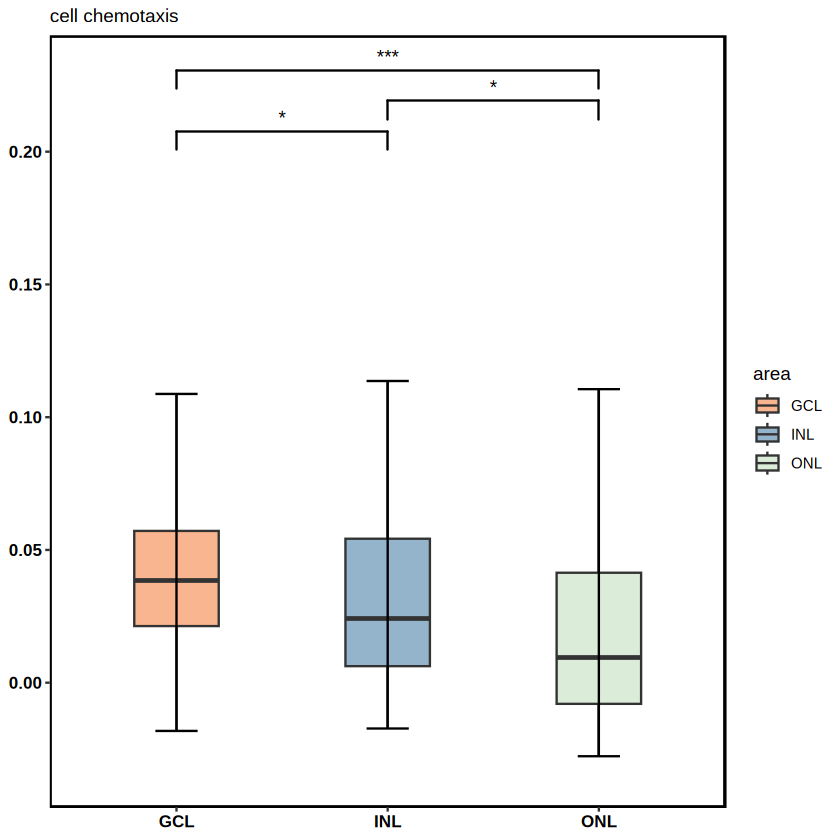

In [65]:
i="cell chemotaxis"
p <- ggplot(m,aes(x=area,y=m[[i]],fill=area))+geom_boxplot(position=position_dodge(width=0.4), width=0.4,alpha=0.5,outlier.shape = NA) +
stat_boxplot(geom="errorbar", position=position_dodge(width=0.4), width=0.2)+#geom_point(aes(fill=area, group=area, color=area), pch=21, size=3,position=position_dodge(0.4)) +
geom_signif(comparisons = list(c('GCL','INL'),c("INL","ONL"),c("GCL","ONL")),map_signif_level = T,test = "wilcox.test",step_increase = 0.05)+
scale_fill_simpsons(alpha=0.7)+scale_color_simpsons(alpha=0.7)+
labs(x=NULL, y=NULL,subtitle = i)+
theme(
    panel.border = element_rect(
      color = "black",
      fill = NA,
      linewidth = 1
    ),panel.background = element_rect(fill = "white")
  )+
theme(axis.text.y=element_text(color="black", size=10, face="bold"), #
axis.text.x=element_text(color="black", size=10, hjust=0.5, face="bold") # 
     )+scale_fill_manual(values = cols) +scale_color_manual(values = cols)#
print(p)
ggsave(paste0(i,"_addscor_microglia.pdf"),p,width = 4,height = 4)

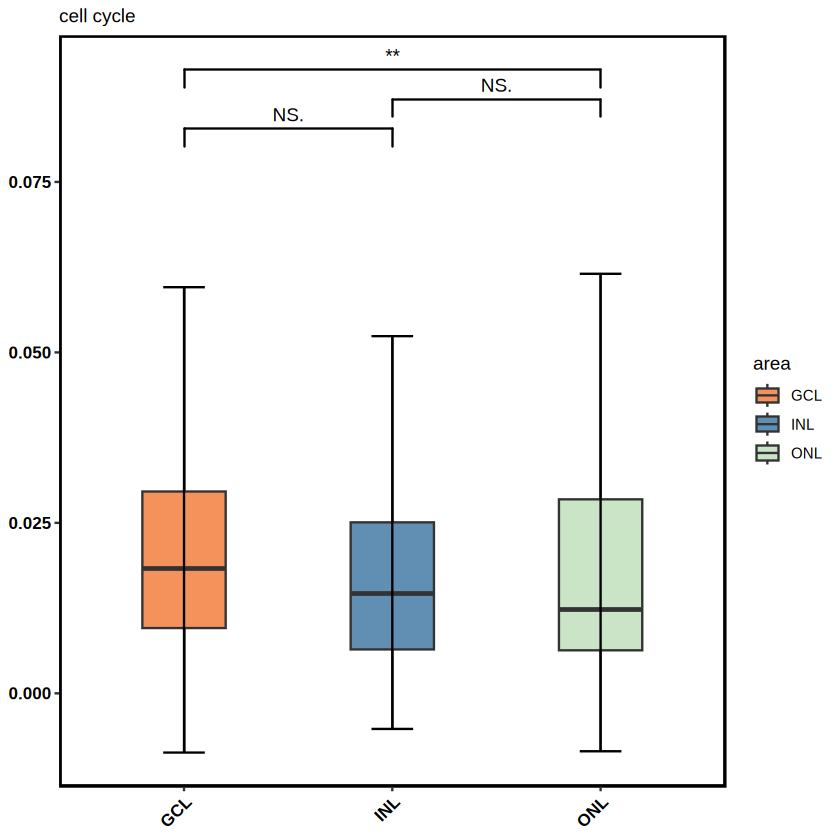

In [51]:
p <- ggplot(m, aes(x = area, y = m[[i]], fill = area)) +
  geom_boxplot(position = position_dodge(width = 0.4), width = 0.4, alpha = 0.75,
               outlier.shape = NA) +          
  stat_boxplot(geom = "errorbar", position = position_dodge(width = 0.4), width = 0.2) +
  geom_signif(comparisons = list(c('GCL','INL'), c('INL','ONL'), c('GCL','ONL')),
              map_signif_level = TRUE, test = "wilcox.test", step_increase = 0.05) +
  scale_fill_manual(values = cols) +
  scale_color_manual(values = cols) +
  labs(x = NULL, y = NULL, subtitle = i) +
  theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
        panel.background = element_rect(fill = "white"),
        axis.text.y = element_text(color = "black", size = 10, face = "bold"),
        axis.text.x = element_text(color = "black", size = 10, hjust = 1, face = "bold", angle = 45))
print(p)

In [136]:
sp1 <- subset(sp,subset = area%in%c("GCL","INL","ONL"))

In [137]:
sp1

An object of class Seurat 
24382 features across 95980 samples within 1 assay 
Active assay: RNA (24382 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

In [138]:
Idents(sp1) <- as.factor(sp1@meta.data$area)

In [139]:
# sp1 <- subset(sp1,subset=nCount_RNA>200)

In [140]:
dim(sp1@meta.data)

[1] 95980    18

In [141]:
sp1 <- subset(x = sp1,downsample = 3000)

In [142]:
table(sp1$area)


 GCL  INL  ONL 
2000 2000 2000 

In [165]:
gene <- c("C5ar1","Cd5l","Rab5a","Cd74","Cxcl10","Cxcl12","Ccl9")

In [166]:
exp <- as.data.frame(sp1@assays$RNA$data)

In [167]:
exp <- exp[gene,]

In [169]:
mer <- merge(subset(sp1@meta.data,select="layer"),t(exp),all=TRUE,by=0)
rownames(mer) <- mer$Row.names
mer <- mer[,-1]

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


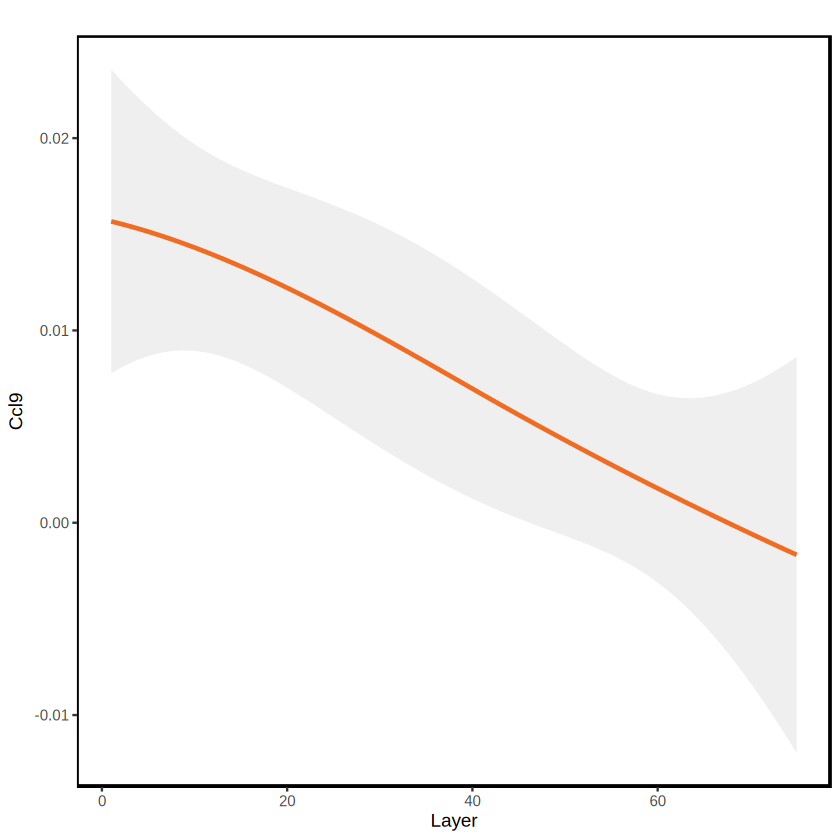

In [170]:
i <- "Ccl9"
p <- ggplot(mer,aes(x=layer,y = Ccl9))+
        labs(subtitle = "")+geom_smooth(method = "loess",span=3,se = T,level=0.95,alpha=0.15,color="#f16c23")+
        labs(y=i,x="Layer",subtitle = "")+
theme(panel.background = element_blank())+#
theme(panel.border = element_rect(color = "black", size = 1, fill = NA))
p
ggsave(paste0(i,"_onl_inl_gcl.pdf"),width = 4,height = 4)